# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

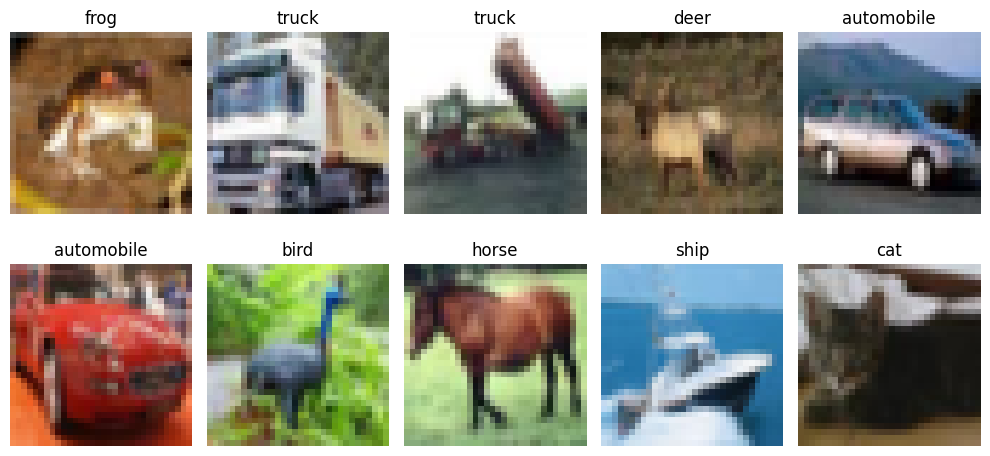

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.2787 - loss: 1.9827 - val_accuracy: 0.3464 - val_loss: 1.8227
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3235 - loss: 1.8551 - val_accuracy: 0.3684 - val_loss: 1.7708
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3444 - loss: 1.8019 - val_accuracy: 0.3626 - val_loss: 1.7605
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3532 - loss: 1.7751 - val_accuracy: 0.3756 - val_loss: 1.7434
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.3628 - loss: 1.7482 - val_accuracy: 0.3638 - val_loss: 1.7443
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3731 - loss: 1.7253 - val_accuracy: 0.4022 - val_loss: 1.7173
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3815 - loss: 1.7052 - val_accuracy: 0.4150 - val_loss: 1.6677
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3856 - loss: 1.6894 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4227 - loss: 1.6428
ANN Test Accuracy: 0.4226999878883362


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 114ms/step - accuracy: 0.4648 - loss: 1.4990 - val_accuracy: 0.4686 - val_loss: 1.4668
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.6057 - loss: 1.1332 - val_accuracy: 0.5490 - val_loss: 1.3089
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.6621 - loss: 0.9646 - val_accuracy: 0.6200 - val_loss: 1.0615
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.7028 - loss: 0.8463 - val_accuracy: 0.5748 - val_loss: 1.4062
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.7427 - loss: 0.7408 - val_accuracy: 0.7040 - val_loss: 0.8438
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.7661 - loss: 0.6605 - val_accuracy: 0.6736 - val_loss: 0.9661
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.7904 - loss: 0.5912 - val_accuracy: 0.7168 - val_loss: 0.8355
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.8137 - loss: 0

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6933 - loss: 1.0479
CNN Test Accuracy: 0.6933000087738037


## 📈 Compare Learning Curves

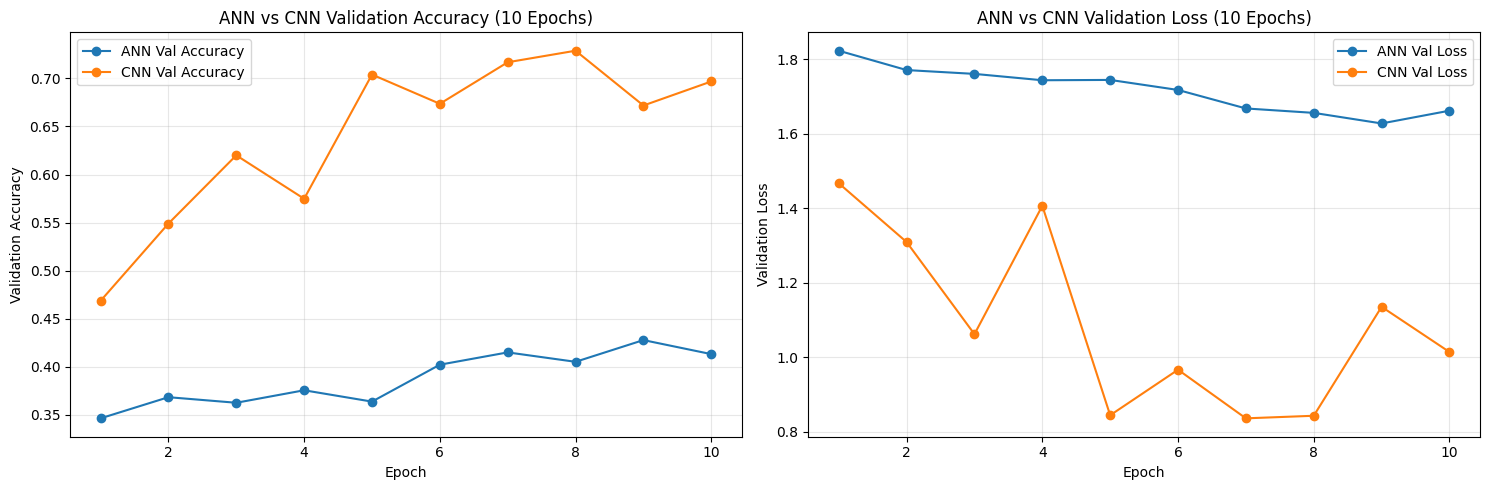

In [9]:
plt.figure(figsize=(15, 5))

# Left plot: Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(
    range(1, len(ann_history.history['val_accuracy']) + 1),
    ann_history.history['val_accuracy'],
    marker='o',
    label='ANN Val Accuracy'
)
plt.plot(
    range(1, len(cnn_history.history['val_accuracy']) + 1),
    cnn_history.history['val_accuracy'],
    marker='o',
    label='CNN Val Accuracy'
)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy (10 Epochs)")
plt.legend()
plt.grid(True, alpha=0.3)

# Right plot: Validation Loss
plt.subplot(1, 2, 2)
plt.plot(
    range(1, len(ann_history.history['val_loss']) + 1),
    ann_history.history['val_loss'],
    marker='o',
    label='ANN Val Loss'
)
plt.plot(
    range(1, len(cnn_history.history['val_loss']) + 1),
    cnn_history.history['val_loss'],
    marker='o',
    label='CNN Val Loss'
)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("ANN vs CNN Validation Loss (10 Epochs)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 116ms/step - accuracy: 0.3539 - loss: 1.8145 - val_accuracy: 0.4786 - val_loss: 1.4606
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.4464 - loss: 1.5434 - val_accuracy: 0.5106 - val_loss: 1.3825
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.4832 - loss: 1.4434 - val_accuracy: 0.5590 - val_loss: 1.2405
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.5178 - loss: 1.3631 - val_accuracy: 0.4818 - val_loss: 1.5150
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 116ms/step - accuracy: 0.5379 - loss: 1.3088 - val_accuracy: 0.5822 - val_loss: 1.1869
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.5547 - loss: 1.2641 - val_accuracy: 0.6204 - val_loss: 1.1056
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.5659 - loss: 1.2326 - val_accuracy: 0.6216 - val_loss: 1.0724
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.5782 - loss: 1

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})

comparison

,Model,Test Accuracy
0,ANN,0.4227
1,CNN,0.6933
2,Augmented CNN,0.6350


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [13]:
# ==========================================================
# Student Learning Tasks
# ==========================================================

from tensorflow.keras.callbacks import EarlyStopping


# ----------------------------------------------------------
# Task 3: Add EarlyStopping
# ----------------------------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


# ----------------------------------------------------------
# Task 4: Add Data Augmentation
# ----------------------------------------------------------

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


# ==========================================================
# Final Improved CNN Model
# ==========================================================

final_model = models.Sequential([

    layers.Input(shape=(32,32,3)),

    data_augmentation,

    # ------------------------------------------------------
    # Task 2: Increase CNN Filters (32 → 64 → 128)
    # ------------------------------------------------------

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    # ------------------------------------------------------
    # Task 1: Increasing Dense Layers
    # ------------------------------------------------------

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(
        10,
        activation='softmax'
    )
])


final_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ----------------------------------------------------------
# Task 5: Increase Epochs to 20
# ----------------------------------------------------------

final_history = final_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)


final_loss, final_acc = final_model.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print("\nFinal Improved Model Accuracy:", final_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 196ms/step - accuracy: 0.3611 - loss: 1.7772 - val_accuracy: 0.4236 - val_loss: 1.6639
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 195ms/step - accuracy: 0.4669 - loss: 1.4801 - val_accuracy: 0.5680 - val_loss: 1.2101
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 199ms/step - accuracy: 0.5232 - loss: 1.3311 - val_accuracy: 0.6214 - val_loss: 1.1286
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 198ms/step - accuracy: 0.5667 - loss: 1.2250 - val_accuracy: 0.5756 - val_loss: 1.2267
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 198ms/step - accuracy: 0.5940 - loss: 1.1505 - val_accuracy: 0.6598 - val_loss: 1.0218
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 194ms/step - accuracy: 0.6172 - loss: 1.0871 - val_accuracy: 0.6760 - val_loss: 0.9383
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 194ms/step - accuracy: 0.6373 - loss: 1.0335 - val_accuracy: 0.6048 - val_loss: 1.1515
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 196ms/step - accuracy: 0.6487 -

In [14]:
task_comparison = pd.DataFrame({
    "Model":[
        "ANN",
        "CNN",
        "Augmented CNN",
        "Final Improved CNN"
    ],
    "Test Accuracy":[
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc,
        final_acc
    ]
})

task_comparison

,Model,Test Accuracy
0,ANN,0.4227
1,CNN,0.6933
2,Augmented CNN,0.6350
3,Final Improved CNN,0.7396


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**